In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install wfdb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 118.1 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatible.
db-dtypes 1.5.0 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.1 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.1 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.1 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you 

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wfdb
import ast
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization, Flatten
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# New path - Google Drive
path = '/content/drive/MyDrive/PTB_XL_Dataset/'

# Load labels
Y = pd.read_csv(path + 'ptbxl_database.csv', index_col='ecg_id')
Y.scp_codes = Y.scp_codes.apply(ast.literal_eval)

print("Database loaded!")
print(f"Total records: {len(Y)}")

Database loaded!
Total records: 21799


In [5]:
# Get diagnostic labels
def get_label(y_dic):
    keys = list(y_dic.keys())
    if len(keys) > 0:
        return keys[0]
    return 'UNKNOWN'

Y['label'] = Y.scp_codes.apply(get_label)

# Keep top 5 classes
top_classes = ['NORM', 'IMI', 'ASMI', 'LVH', 'LAFB']
Y_filtered = Y[Y['label'].isin(top_classes)]

print(f"Filtered records: {len(Y_filtered)}")
print(Y_filtered['label'].value_counts())

Filtered records: 15612
label
NORM    9514
IMI     2317
ASMI    1879
LVH     1212
LAFB     690
Name: count, dtype: int64


In [6]:
X = np.load('/content/drive/MyDrive/PTB_XL_Dataset/X_data.npy')
y = np.load('/content/drive/MyDrive/PTB_XL_Dataset/y_data.npy', allow_pickle=True)
print(f"Signal shape: {X.shape}")
print(f"Labels shape: {y.shape}")

Signal shape: (15612, 1000, 12)
Labels shape: (15612,)


In [7]:
import numpy as np
np.save('/content/drive/MyDrive/PTB_XL_Dataset/X_data.npy', X)
np.save('/content/drive/MyDrive/PTB_XL_Dataset/y_data.npy', y)
print("Data saved!")

Data saved!


In [8]:
from sklearn.utils import resample

min_samples = 690
balanced_X = []
balanced_y = []

for cls in ['NORM', 'IMI', 'ASMI', 'LVH', 'LAFB']:
    idx = np.where(y == cls)[0]
    idx_balanced = resample(idx, n_samples=min_samples, random_state=42)
    balanced_X.append(X[idx_balanced])
    balanced_y.append(y[idx_balanced])

X_balanced = np.concatenate(balanced_X)
y_balanced = np.concatenate(balanced_y)

print(f"Balanced dataset: {X_balanced.shape}")
print(f"Per class: {min_samples} each")

Balanced dataset: (3450, 1000, 12)
Per class: 690 each


In [9]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

le = LabelEncoder()
y_encoded = le.fit_transform(y_balanced)

X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Classes: {le.classes_}")
print(f"Train: {X_train.shape}")
print(f"Test: {X_test.shape}")

Classes: ['ASMI' 'IMI' 'LAFB' 'LVH' 'NORM']
Train: (2760, 1000, 12)
Test: (690, 1000, 12)


In [12]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.models import Sequential

model = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(1000, 12)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Conv1D(128, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Conv1D(256, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Conv1D(128, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    LSTM(256, return_sequences=True),
    LSTM(128, return_sequences=False),
    Dropout(0.5),

    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(5, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_7 (Conv1D)               │ (None, 998, 64)        │         2,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 998, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 499, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 497, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 497, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_8 (MaxPooling1D)  │ (None, 248, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 246, 256)       │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 246, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_9 (MaxPooling1D)  │ (None, 123, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_10 (Conv1D)              │ (None, 121, 128)       │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 121, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_10 (MaxPooling1D) │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 60, 256)        │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 128)            │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 884,293 (3.37 MB)

 Trainable params: 883,141 (3.37 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [13]:
early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, reduce_lr]
)
print("Training complete!")

Epoch 1/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/step - accuracy: 0.5178 - loss: 1.2314 - val_accuracy: 0.2652 - val_loss: 2.0807 - learning_rate: 0.0010
Epoch 2/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.6851 - loss: 0.9335 - val_accuracy: 0.2812 - val_loss: 2.1734 - learning_rate: 0.0010
Epoch 3/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.7033 - loss: 0.8794 - val_accuracy: 0.4739 - val_loss: 1.2749 - learning_rate: 0.0010
Epoch 4/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.7652 - loss: 0.7076 - val_accuracy: 0.6333 - val_loss: 1.1130 - learning_rate: 0.0010
Epoch 5/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.7732 - loss: 0.6739 - val_accuracy: 0.6333 - val_loss: 1.0179 - learning_rate: 0.0010
Epoch 6/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.7873 - loss: 0.6123 - val_accuracy: 0.7580 - val_loss: 0.6841 - learning_rate: 0.0010
Epoch 7/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.8022 - loss: 0.5835 - val_ac

In [14]:
# Evaluation
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy*100:.2f}%")
print(f"Test Loss: {loss:.4f}")

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8565 - loss: 0.5257
Test Accuracy: 85.65%
Test Loss: 0.5257


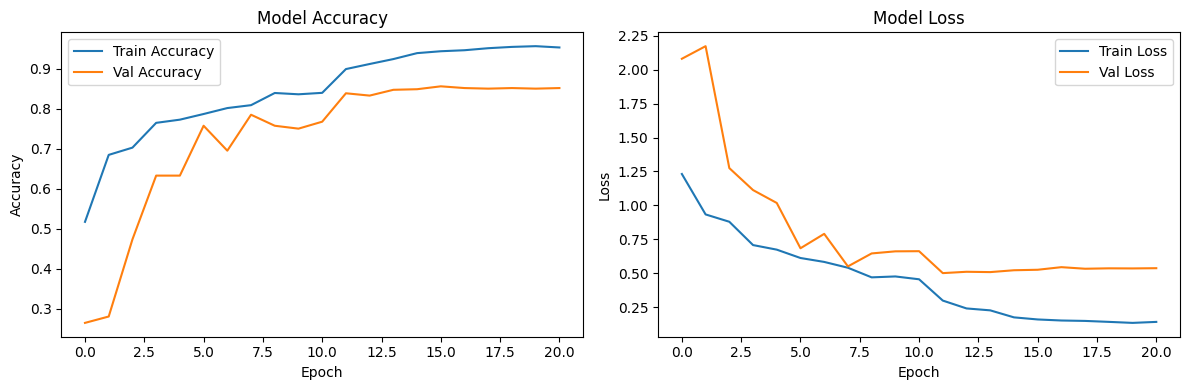

Graph saved!


In [15]:
# Training Graphs
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('training_graphs_signal.png')
plt.show()
print("Graph saved!")

In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step


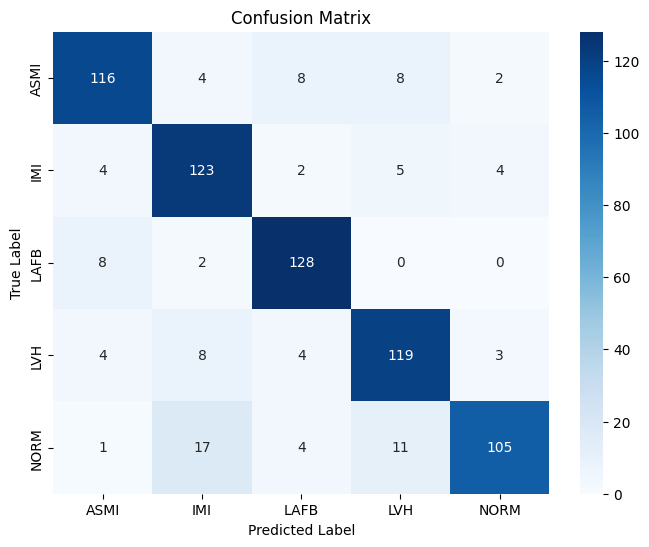

              precision    recall  f1-score   support

        ASMI       0.87      0.84      0.86       138
         IMI       0.80      0.89      0.84       138
        LAFB       0.88      0.93      0.90       138
         LVH       0.83      0.86      0.85       138
        NORM       0.92      0.76      0.83       138

    accuracy                           0.86       690
   macro avg       0.86      0.86      0.86       690
weighted avg       0.86      0.86      0.86       690



In [17]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig('confusion_matrix_signal.png')
plt.show()

print(classification_report(y_test, y_pred_classes, target_names=le.classes_))

In [18]:
model.save('ecg_signal_model_v2.h5')
print("Model saved!")

Model saved!
